In [2]:
# Cell 1: Import libraries and load data
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better viewing in Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# File path
file_path = r"C:\neww\FYP\microloan-credit-scoring\backend\data\application_train.csv" 

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
else:
    file_size = os.path.getsize(file_path)
    print(f"File found: {file_size:,} bytes ({file_size/(1024**2):.2f} MB)")

# Define columns needed
columns_needed = [
    "DAYS_BIRTH", "AMT_INCOME_TOTAL", "AMT_ANNUITY", 
    "AMT_CREDIT", "NAME_CONTRACT_TYPE", "CODE_GENDER"
]

# Load data
print("\nLoading data...")
df = pd.read_csv(file_path, usecols=columns_needed, nrows=100000)
print(f"Loaded {len(df):,} rows with {len(df.columns)} columns")

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Cell 2: Data cleaning and preprocessing
print("Data Cleaning")
print("="*50)

# Convert age from days to years
if 'DAYS_BIRTH' in df.columns:
    df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365.25
    df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], 
                             bins=[0, 18, 25, 35, 45, 55, 65, 100],
                             labels=['<18', '18-25', '25-35', '35-45', '45-55', '55-65', '65+'])
    print("✓ Age column created")

# Remove invalid values
df_clean = df.dropna()
original_len = len(df_clean)

if 'AMT_INCOME_TOTAL' in df_clean.columns:
    df_clean = df_clean[df_clean['AMT_INCOME_TOTAL'] > 0]
if 'AMT_ANNUITY' in df_clean.columns:
    df_clean = df_clean[df_clean['AMT_ANNUITY'] > 0]
if 'AMT_CREDIT' in df_clean.columns:
    df_clean = df_clean[df_clean['AMT_CREDIT'] > 0]

print(f"Rows after cleaning: {len(df_clean):,} (from {original_len:,})")

# Calculate ratios
if 'AMT_INCOME_TOTAL' in df_clean.columns and 'AMT_ANNUITY' in df_clean.columns:
    df_clean['INCOME_TO_ANNUITY'] = df_clean['AMT_INCOME_TOTAL'] / df_clean['AMT_ANNUITY']
    print("✓ Income/Annuity ratio calculated")

if 'AMT_CREDIT' in df_clean.columns and 'AMT_INCOME_TOTAL' in df_clean.columns:
    df_clean['CREDIT_TO_INCOME'] = df_clean['AMT_CREDIT'] / df_clean['AMT_INCOME_TOTAL']
    print("✓ Credit/Income ratio calculated")

if 'AMT_ANNUITY' in df_clean.columns and 'AMT_CREDIT' in df_clean.columns:
    df_clean['ANNUITY_TO_CREDIT'] = df_clean['AMT_ANNUITY'] / df_clean['AMT_CREDIT']
    print("✓ Annuity/Credit ratio calculated")

Data Cleaning
✓ Age column created
Rows after cleaning: 99,993 (from 99,993)
✓ Income/Annuity ratio calculated
✓ Credit/Income ratio calculated
✓ Annuity/Credit ratio calculated


METRIC 1: USER AGE INTERVAL

Total samples count: 99,993

Statistics:
  Minimum: 21 years
  Maximum: 69 years
  Mean: 43.9 years
  Median: 43.1 years
  Standard Deviation: 12.0 years

Distribution:
  <18      :      0 (  0.0%) 
  18-25    :  4,046 (  4.0%) ██
  25-35    : 23,583 ( 23.6%) ███████████
  35-45    : 27,314 ( 27.3%) █████████████
  45-55    : 22,853 ( 22.9%) ███████████
  55-65    : 19,659 ( 19.7%) █████████
  65+      :  2,538 (  2.5%) █


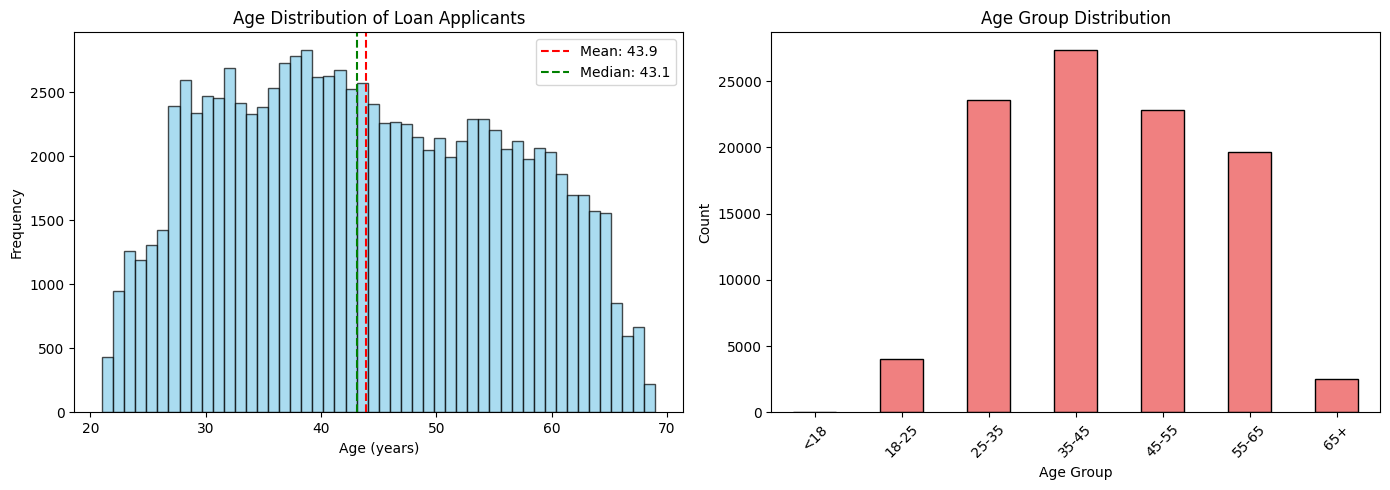

In [ ]:
# Cell 3: METRIC 1 - USER AGE INTERVAL
print("="*80)
print("METRIC 1: USER AGE INTERVAL")
print("="*80)

if 'AGE_YEARS' in df_clean.columns:
    # Total samples count
    print(f"\nTotal samples count: {len(df_clean):,}")
    
    # Statistics
    print(f"\nStatistics:")
    print(f"  Minimum: {df_clean['AGE_YEARS'].min():.0f} years")
    print(f"  Maximum: {df_clean['AGE_YEARS'].max():.0f} years")
    print(f"  Mean: {df_clean['AGE_YEARS'].mean():.1f} years")
    print(f"  Median: {df_clean['AGE_YEARS'].median():.1f} years")
    print(f"  Standard Deviation: {df_clean['AGE_YEARS'].std():.1f} years")
    
    # Distribution
    age_dist = df_clean['AGE_GROUP'].value_counts().sort_index()
    print(f"\nDistribution:")
    for group, count in age_dist.items():
        pct = (count / len(df_clean)) * 100
        bar = "█" * int(pct / 2)
        print(f"  {group:8} : {count:6,} ({pct:5.1f}%) {bar}")
    
    # Optional: Create a visualization in Jupyter
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df_clean['AGE_YEARS'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].axvline(df_clean['AGE_YEARS'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["AGE_YEARS"].mean():.1f}')
    axes[0].axvline(df_clean['AGE_YEARS'].median(), color='green', linestyle='--', label=f'Median: {df_clean["AGE_YEARS"].median():.1f}')
    axes[0].set_xlabel('Age (years)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Age Distribution of Loan Applicants')
    axes[0].legend()
    
    # Bar chart by age group
    age_dist.plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
    axes[1].set_xlabel('Age Group')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Age Group Distribution')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

METRIC 2: INCOME TO ANNUITY RATIO (Income / Annuity)

Total samples count: 99,993

Statistics:
  Mean: 7.4x
  Median: 6.1x
  Minimum: 0.5x
  Maximum: 4466.6x
  Standard Deviation: 14.9x

Percentiles:
  10th percentile: 3.3x
  25th percentile: 4.4x
  50th percentile: 6.1x
  75th percentile: 8.7x
  90th percentile: 12.5x

Distribution:
  <2x        :    781 (  0.8%) █
  2-3x       :  5,861 (  5.9%) ███████████
  3-4x       : 12,643 ( 12.6%) █████████████████████████
  4-5x       : 14,999 ( 15.0%) ██████████████████████████████
  5-6x       : 13,960 ( 14.0%) ███████████████████████████
  6-7x       : 12,148 ( 12.1%) ████████████████████████
  7-8x       :  9,272 (  9.3%) ██████████████████
  8-9x       :  6,991 (  7.0%) █████████████
  9-10x      :  4,849 (  4.8%) █████████
  10-12x     :  7,035 (  7.0%) ██████████████
  12-15x     :  5,235 (  5.2%) ██████████
  15-20x     :  3,627 (  3.6%) ███████
  20-30x     :  1,982 (  2.0%) ███
  >30x       :    601 (  0.6%) █


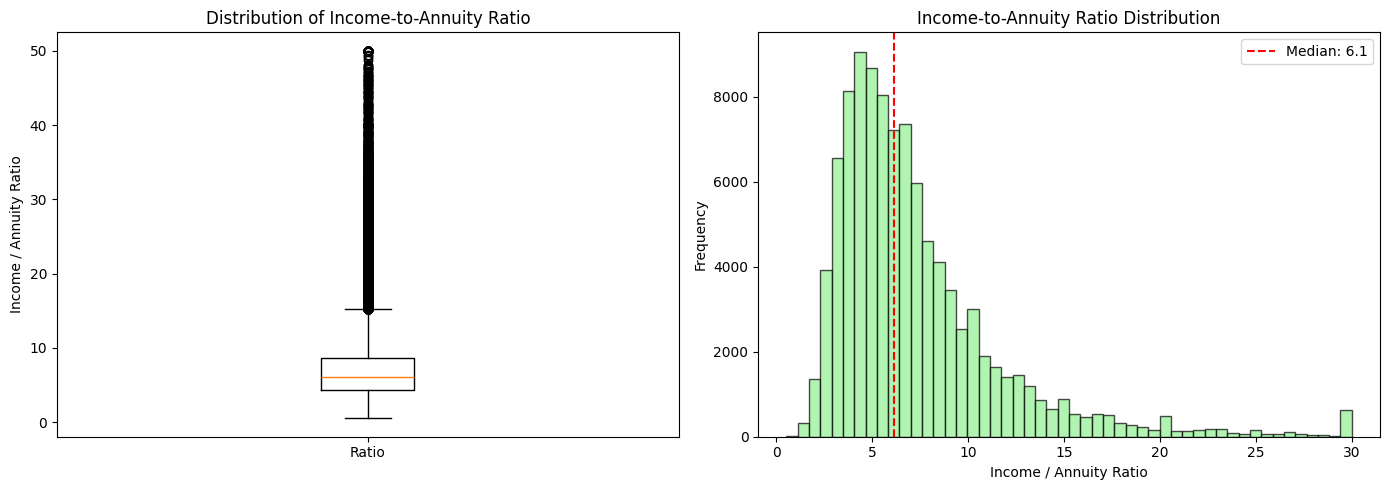

In [ ]:
# Cell 4: METRIC 2 - INCOME TO ANNUITY RATIO
print("="*80)
print("METRIC 2: INCOME TO ANNUITY RATIO (Income / Annuity)")
print("="*80)

if 'INCOME_TO_ANNUITY' in df_clean.columns:
    # Total samples count
    print(f"\nTotal samples count: {len(df_clean):,}")
    
    # Statistics
    stats = df_clean['INCOME_TO_ANNUITY'].describe()
    print(f"\nStatistics:")
    print(f"  Mean: {stats['mean']:.1f}x")
    print(f"  Median: {stats['50%']:.1f}x")
    print(f"  Minimum: {stats['min']:.1f}x")
    print(f"  Maximum: {stats['max']:.1f}x")
    print(f"  Standard Deviation: {stats['std']:.1f}x")
    
    # Percentile breakdown
    print(f"\nPercentiles:")
    for p in [10, 25, 50, 75, 90]:
        val = df_clean['INCOME_TO_ANNUITY'].quantile(p/100)
        print(f"  {p}th percentile: {val:.1f}x")
    
    # Distribution
    income_annuity_bins = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 100]
    income_annuity_labels = ['<2x', '2-3x', '3-4x', '4-5x', '5-6x', '6-7x', '7-8x', 
                             '8-9x', '9-10x', '10-12x', '12-15x', '15-20x', '20-30x', '>30x']
    
    df_clean['INCOME_ANNUITY_GROUP'] = pd.cut(df_clean['INCOME_TO_ANNUITY'], 
                                               bins=income_annuity_bins, 
                                               labels=income_annuity_labels,
                                               right=False)
    
    income_annuity_dist = df_clean['INCOME_ANNUITY_GROUP'].value_counts().sort_index()
    
    print(f"\nDistribution:")
    max_count = income_annuity_dist.max()
    max_bar_width = 30
    
    for group, count in income_annuity_dist.items():
        pct = (count / len(df_clean)) * 100
        bar_width = max(1, int((count / max_count) * max_bar_width))
        bar = "█" * bar_width
        print(f"  {group:10} : {count:6,} ({pct:5.1f}%) {bar}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Box plot
    axes[0].boxplot(df_clean['INCOME_TO_ANNUITY'].clip(upper=50))
    axes[0].set_ylabel('Income / Annuity Ratio')
    axes[0].set_title('Distribution of Income-to-Annuity Ratio')
    axes[0].set_xticklabels(['Ratio'])
    
    # Histogram
    axes[1].hist(df_clean['INCOME_TO_ANNUITY'].clip(upper=30), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1].axvline(df_clean['INCOME_TO_ANNUITY'].median(), color='red', linestyle='--', label=f'Median: {df_clean["INCOME_TO_ANNUITY"].median():.1f}')
    axes[1].set_xlabel('Income / Annuity Ratio')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Income-to-Annuity Ratio Distribution')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

METRIC 3: CREDIT TO INCOME RATIO (Credit / Income)

Total samples count: 99,993

Statistics:
  Mean: 3.96x
  Median: 3.28x
  Minimum: 0.00x
  Maximum: 84.74x
  Standard Deviation: 2.69x

Percentiles:
  10th percentile: 1.33x
  25th percentile: 2.02x
  50th percentile: 3.28x
  75th percentile: 5.17x
  90th percentile: 7.49x

Distribution:
  <0.5x        :    543 (  0.5%) █
  0.5-1x       :  4,138 (  4.1%) ███████
  1-1.5x       :  8,468 (  8.5%) ███████████████
  1.5-2x       :  9,944 (  9.9%) ██████████████████
  2-2.5x       : 10,994 ( 11.0%) ███████████████████
  2.5-3x       : 10,391 ( 10.4%) ██████████████████
  3-4x         : 16,536 ( 16.5%) ██████████████████████████████
  4-5x         : 11,685 ( 11.7%) █████████████████████
  5-6x         :  8,991 (  9.0%) ████████████████
  6-8x         : 10,210 ( 10.2%) ██████████████████
  8-10x        :  4,545 (  4.5%) ████████
  10-15x       :  3,106 (  3.1%) █████
  15-20x       :    365 (  0.4%) █
  >20x         :     77 (  0.1%) █

Cumul

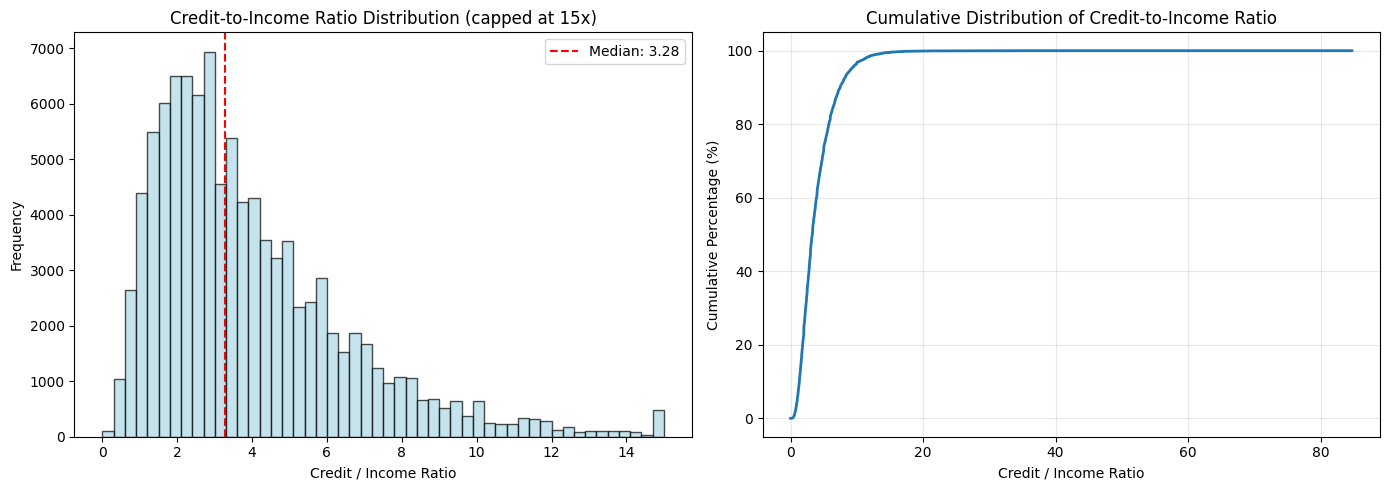

In [ ]:
# Cell 5: METRIC 3 - CREDIT TO INCOME RATIO
print("="*80)
print("METRIC 3: CREDIT TO INCOME RATIO (Credit / Income)")
print("="*80)

if 'CREDIT_TO_INCOME' in df_clean.columns:
    # Total samples count
    print(f"\nTotal samples count: {len(df_clean):,}")
    
    # Statistics
    stats = df_clean['CREDIT_TO_INCOME'].describe()
    print(f"\nStatistics:")
    print(f"  Mean: {stats['mean']:.2f}x")
    print(f"  Median: {stats['50%']:.2f}x")
    print(f"  Minimum: {stats['min']:.2f}x")
    print(f"  Maximum: {stats['max']:.2f}x")
    print(f"  Standard Deviation: {stats['std']:.2f}x")
    
    # Percentile breakdown
    print(f"\nPercentiles:")
    for p in [10, 25, 50, 75, 90]:
        val = df_clean['CREDIT_TO_INCOME'].quantile(p/100)
        print(f"  {p}th percentile: {val:.2f}x")
    
    # Distribution
    credit_income_bins = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 10, 15, 20, 100]
    credit_income_labels = ['<0.5x', '0.5-1x', '1-1.5x', '1.5-2x', '2-2.5x', 
                            '2.5-3x', '3-4x', '4-5x', '5-6x', '6-8x', 
                            '8-10x', '10-15x', '15-20x', '>20x']
    
    df_clean['CREDIT_INCOME_GROUP'] = pd.cut(df_clean['CREDIT_TO_INCOME'], 
                                              bins=credit_income_bins, 
                                              labels=credit_income_labels,
                                              right=False)
    
    credit_income_dist = df_clean['CREDIT_INCOME_GROUP'].value_counts().sort_index()
    
    print(f"\nDistribution:")
    max_count = credit_income_dist.max()
    max_bar_width = 30
    
    for group, count in credit_income_dist.items():
        pct = (count / len(df_clean)) * 100
        bar_width = max(1, int((count / max_count) * max_bar_width))
        bar = "█" * bar_width
        print(f"  {group:12} : {count:6,} ({pct:5.1f}%) {bar}")
    
    # Cumulative distribution
    print(f"\nCumulative Distribution:")
    cumulative_pct = 0
    for group, count in credit_income_dist.items():
        pct = (count / len(df_clean)) * 100
        cumulative_pct += pct
        print(f"  Up to {group:12} : {cumulative_pct:5.1f}%")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram (capped at 15x for better visibility)
    capped_data = df_clean['CREDIT_TO_INCOME'].clip(upper=15)
    axes[0].hist(capped_data, bins=50, edgecolor='black', alpha=0.7, color='lightblue')
    axes[0].axvline(df_clean['CREDIT_TO_INCOME'].median(), color='red', linestyle='--', 
                    label=f'Median: {df_clean["CREDIT_TO_INCOME"].median():.2f}')
    axes[0].set_xlabel('Credit / Income Ratio')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Credit-to-Income Ratio Distribution (capped at 15x)')
    axes[0].legend()
    
    # Cumulative distribution plot
    sorted_ratios = np.sort(df_clean['CREDIT_TO_INCOME'])
    cumulative = np.arange(1, len(sorted_ratios) + 1) / len(sorted_ratios) * 100
    axes[1].plot(sorted_ratios, cumulative, linewidth=2)
    axes[1].set_xlabel('Credit / Income Ratio')
    axes[1].set_ylabel('Cumulative Percentage (%)')
    axes[1].set_title('Cumulative Distribution of Credit-to-Income Ratio')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

METRIC 4: ANNUITY TO CREDIT RATIO (Annuity / Credit)

Total samples count: 99,993

Statistics:
  Mean: 0.0537 (5.4%)
  Median: 0.0500 (5.0%)
  Minimum: 0.0221 (2.2%)
  Maximum: 0.1244 (12.4%)
  Standard Deviation: 0.0224

Percentiles:
  10th percentile: 0.0294 (2.9%)
  25th percentile: 0.0369 (3.7%)
  50th percentile: 0.0500 (5.0%)
  75th percentile: 0.0639 (6.4%)
  90th percentile: 0.0950 (9.5%)

Distribution:
  <3%        : 13,412 ( 13.4%) ████████████████████
  3-4%       : 18,668 ( 18.7%) ████████████████████████████
  4-4.5%     :  7,594 (  7.6%) ███████████
  4.5-5%     :  9,151 (  9.2%) █████████████
  5-5.5%     : 19,813 ( 19.8%) ██████████████████████████████
  5.5-6%     :  4,035 (  4.0%) ██████
  6-7%       :  7,967 (  8.0%) ████████████
  7-8%       :  6,893 (  6.9%) ██████████
  8-9%       :  1,265 (  1.3%) █
  9-10%      :  4,822 (  4.8%) ███████
  10-12%     :  6,266 (  6.3%) █████████
  12-15%     :    107 (  0.1%) █
  >15%       :      0 (  0.0%) █

Implied Loan Term (

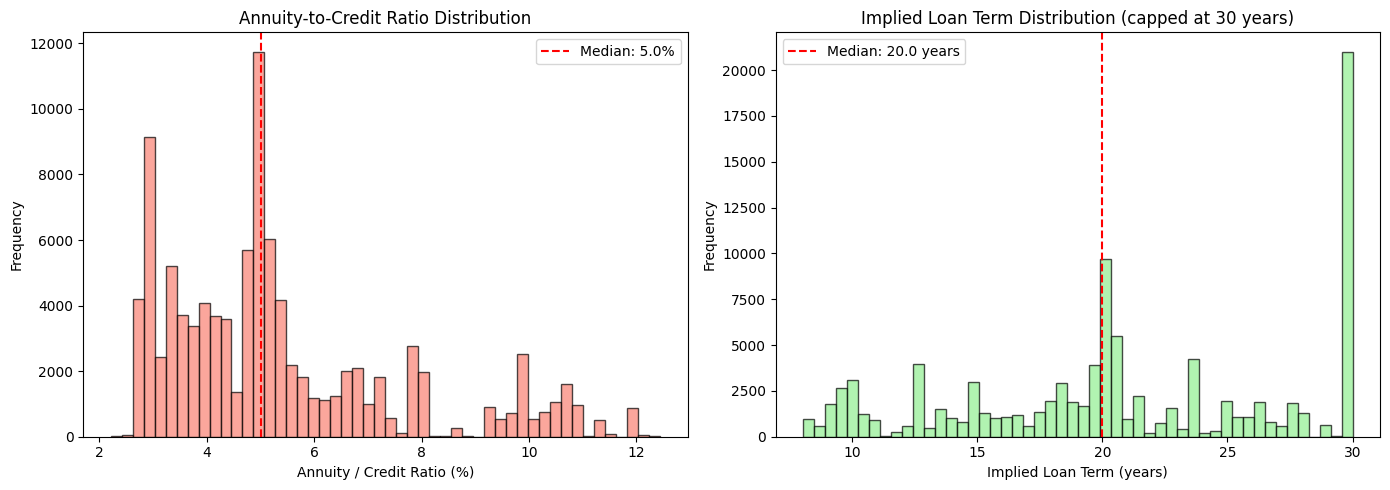

In [ ]:
# Cell 6: METRIC 4 - ANNUITY TO CREDIT RATIO
print("="*80)
print("METRIC 4: ANNUITY TO CREDIT RATIO (Annuity / Credit)")
print("="*80)

if 'ANNUITY_TO_CREDIT' in df_clean.columns:
    # Total samples count
    print(f"\nTotal samples count: {len(df_clean):,}")
    
    # Statistics
    stats = df_clean['ANNUITY_TO_CREDIT'].describe()
    print(f"\nStatistics:")
    print(f"  Mean: {stats['mean']:.4f} ({stats['mean']*100:.1f}%)")
    print(f"  Median: {stats['50%']:.4f} ({stats['50%']*100:.1f}%)")
    print(f"  Minimum: {stats['min']:.4f} ({stats['min']*100:.1f}%)")
    print(f"  Maximum: {stats['max']:.4f} ({stats['max']*100:.1f}%)")
    print(f"  Standard Deviation: {stats['std']:.4f}")
    
    # Percentile breakdown
    print(f"\nPercentiles:")
    for p in [10, 25, 50, 75, 90]:
        val = df_clean['ANNUITY_TO_CREDIT'].quantile(p/100)
        print(f"  {p}th percentile: {val:.4f} ({val*100:.1f}%)")
    
    # Distribution
    annuity_credit_bins = [0, 0.03, 0.04, 0.045, 0.05, 0.055, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12, 0.15, 0.20]
    annuity_credit_labels = ['<3%', '3-4%', '4-4.5%', '4.5-5%', '5-5.5%', '5.5-6%', 
                             '6-7%', '7-8%', '8-9%', '9-10%', '10-12%', '12-15%', '>15%']
    
    df_clean['ANNUITY_CREDIT_GROUP'] = pd.cut(df_clean['ANNUITY_TO_CREDIT'], 
                                               bins=annuity_credit_bins, 
                                               labels=annuity_credit_labels,
                                               right=False)
    
    annuity_credit_dist = df_clean['ANNUITY_CREDIT_GROUP'].value_counts().sort_index()
    
    print(f"\nDistribution:")
    max_count = annuity_credit_dist.max()
    max_bar_width = 30
    
    for group, count in annuity_credit_dist.items():
        pct = (count / len(df_clean)) * 100
        bar_width = max(1, int((count / max_count) * max_bar_width))
        bar = "█" * bar_width
        print(f"  {group:10} : {count:6,} ({pct:5.1f}%) {bar}")
    
    # Implied loan term
    df_clean['IMPLIED_TERM_YEARS'] = 1 / df_clean['ANNUITY_TO_CREDIT']
    term_stats = df_clean['IMPLIED_TERM_YEARS'].describe()
    print(f"\nImplied Loan Term (if simple interest, no compounding):")
    print(f"  Mean: {term_stats['mean']:.1f} years")
    print(f"  Median: {term_stats['50%']:.1f} years")
    print(f"  Minimum: {term_stats['min']:.1f} years")
    print(f"  Maximum: {term_stats['max']:.1f} years")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df_clean['ANNUITY_TO_CREDIT'] * 100, bins=50, edgecolor='black', alpha=0.7, color='salmon')
    axes[0].axvline(df_clean['ANNUITY_TO_CREDIT'].median() * 100, color='red', linestyle='--', 
                    label=f'Median: {df_clean["ANNUITY_TO_CREDIT"].median()*100:.1f}%')
    axes[0].set_xlabel('Annuity / Credit Ratio (%)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Annuity-to-Credit Ratio Distribution')
    axes[0].legend()
    
    # Implied loan term distribution
    axes[1].hist(df_clean['IMPLIED_TERM_YEARS'].clip(upper=30), bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1].axvline(df_clean['IMPLIED_TERM_YEARS'].median(), color='red', linestyle='--', 
                    label=f'Median: {df_clean["IMPLIED_TERM_YEARS"].median():.1f} years')
    axes[1].set_xlabel('Implied Loan Term (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Implied Loan Term Distribution (capped at 30 years)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 6.1: DEEP ANALYSIS OF <3% ANNUITY TO CREDIT RATIO GROUP
print("="*80)
print("DEEP ANALYSIS: ANNUITY TO CREDIT RATIO < 3% GROUP")
print("="*80)

if 'ANNUITY_TO_CREDIT' in df_clean.columns:
    # Filter the low annuity ratio group
    low_annuity_group = df_clean[df_clean['ANNUITY_TO_CREDIT'] < 0.03]
    
    print(f"\n{'='*60}")
    print(f"GROUP SIZE ANALYSIS")
    print(f"{'='*60}")
    print(f"Total samples: {len(df_clean):,}")
    print(f"Samples with Annuity/Credit < 3%: {len(low_annuity_group):,}")
    print(f"Percentage of total: {(len(low_annuity_group)/len(df_clean)*100):.2f}%")
    
    # Statistics for this subgroup
    print(f"\n{'='*60}")
    print(f"STATISTICS FOR <3% GROUP")
    print(f"{'='*60}")
    stats_low = low_annuity_group['ANNUITY_TO_CREDIT'].describe()
    print(f"Mean: {stats_low['mean']:.4f} ({stats_low['mean']*100:.2f}%)")
    print(f"Median: {stats_low['50%']:.4f} ({stats_low['50%']*100:.2f}%)")
    print(f"Minimum: {stats_low['min']:.4f} ({stats_low['min']*100:.2f}%)")
    print(f"Maximum: {stats_low['max']:.4f} ({stats_low['max']*100:.2f}%)")
    print(f"Standard Deviation: {stats_low['std']:.4f}")
    
    # Detailed percentile breakdown within <3% group
    print(f"\n{'='*60}")
    print(f"DETAILED PERCENTILES WITHIN <3% GROUP")
    print(f"{'='*60}")
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        val = low_annuity_group['ANNUITY_TO_CREDIT'].quantile(p/100)
        print(f"  {p}th percentile: {val:.4f} ({val*100:.2f}%)")
    
    # Distribution within the <3% range (0.5% increments)
    print(f"\n{'='*60}")
    print(f"DETAILED DISTRIBUTION WITHIN <3% RANGE")
    print(f"{'='*60}")
    
    # Define fine-grained bins for 0% to 3%
    fine_bins = [0, 0.005, 0.01, 0.015, 0.02, 0.022, 0.024, 0.026, 0.028, 0.03]
    fine_labels = ['<0.5%', '0.5-1.0%', '1.0-1.5%', '1.5-2.0%', '2.0-2.2%', 
                   '2.2-2.4%', '2.4-2.6%', '2.6-2.8%', '2.8-3.0%']
    
    low_annuity_group['ANNUITY_DETAIL_GROUP'] = pd.cut(low_annuity_group['ANNUITY_TO_CREDIT'], 
                                                        bins=fine_bins, 
                                                        labels=fine_labels,
                                                        right=False)
    
    detailed_dist = low_annuity_group['ANNUITY_DETAIL_GROUP'].value_counts().sort_index()
    
    print(f"\nDistribution of Annuity/Credit Ratio within <3% group:")
    print(f"  Total in this analysis: {len(low_annuity_group):,}")
    print()
    
    max_count = detailed_dist.max()
    max_bar_width = 40
    
    for group, count in detailed_dist.items():
        pct_of_low_group = (count / len(low_annuity_group)) * 100
        pct_of_total = (count / len(df_clean)) * 100
        bar_width = max(1, int((count / max_count) * max_bar_width))
        bar = "█" * bar_width
        print(f"  {group:12} : {count:6,} ({pct_of_low_group:5.1f}% of <3% group, {pct_of_total:5.2f}% of total) {bar}")
    
    # Compare with other metrics for this group
    print(f"\n{'='*60}")
    print(f"OTHER METRICS FOR <3% ANNUITY GROUP VS NORMAL GROUP")
    print(f"{'='*60}")
    
    # Create comparison groups
    normal_group = df_clean[df_clean['ANNUITY_TO_CREDIT'] >= 0.03]
    
    metrics_to_compare = ['CREDIT_TO_INCOME', 'INCOME_TO_ANNUITY', 'AGE_YEARS']
    metric_names = ['Credit/Income Ratio', 'Income/Annuity Ratio', 'Age (years)']
    
    for metric, name in zip(metrics_to_compare, metric_names):
        if metric in df_clean.columns:
            low_median = low_annuity_group[metric].median()
            normal_median = normal_group[metric].median()
            low_mean = low_annuity_group[metric].mean()
            normal_mean = normal_group[metric].mean()
            
            print(f"\n{name}:")
            print(f"  <3% Annuity Group - Median: {low_median:.2f}, Mean: {low_mean:.2f}")
            print(f"  Normal Group (>=3%) - Median: {normal_median:.2f}, Mean: {normal_mean:.2f}")
            print(f"  Difference: {(low_median - normal_median):.2f}")
    
    # Credit/Income ratio distribution for this group
    if 'CREDIT_TO_INCOME' in low_annuity_group.columns:
        print(f"\n{'='*60}")
        print(f"CREDIT/INCOME RATIO DISTRIBUTION FOR <3% ANNUITY GROUP")
        print(f"{'='*60}")
        
        ci_bins = [0, 1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 100]
        ci_labels = ['<1x', '1-2x', '2-3x', '3-4x', '4-5x', '5-6x', '6-8x', '8-10x', '10-15x', '15-20x', '>20x']
        
        low_annuity_group['CI_GROUP'] = pd.cut(low_annuity_group['CREDIT_TO_INCOME'], 
                                                bins=ci_bins, 
                                                labels=ci_labels,
                                                right=False)
        
        ci_dist = low_annuity_group['CI_GROUP'].value_counts().sort_index()
        
        print(f"\nCredit/Income distribution within <3% Annuity group:")
        max_count = ci_dist.max()
        max_bar_width = 30
        
        for group, count in ci_dist.items():
            pct = (count / len(low_annuity_group)) * 100
            bar_width = max(1, int((count / max_count) * max_bar_width))
            bar = "█" * bar_width
            print(f"  {group:8} : {count:6,} ({pct:5.1f}%) {bar}")
    
    # Age group distribution for this group
    if 'AGE_GROUP' in low_annuity_group.columns:
        print(f"\n{'='*60}")
        print(f"AGE GROUP DISTRIBUTION FOR <3% ANNUITY GROUP")
        print(f"{'='*60}")
        
        age_dist_low = low_annuity_group['AGE_GROUP'].value_counts().sort_index()
        age_dist_normal = normal_group['AGE_GROUP'].value_counts().sort_index()
        
        print(f"\nAge Group Comparison:")
        print(f"  {'Age Group':10} | {'<3% Group':>12} | {'Normal Group':>12} | {'Difference':>10}")
        print(f"  {'-'*10} | {'-'*12} | {'-'*12} | {'-'*10}")
        
        for age_group in age_dist_low.index:
            low_pct = (age_dist_low[age_group] / len(low_annuity_group)) * 100
            normal_pct = (age_dist_normal[age_group] / len(normal_group)) * 100 if age_group in age_dist_normal.index else 0
            diff = low_pct - normal_pct
            print(f"  {age_group:10} | {low_pct:11.1f}% | {normal_pct:11.1f}% | {diff:9.1f}%")
    
    # Implied loan term for this group
    print(f"\n{'='*60}")
    print(f"IMPLIED LOAN TERM FOR <3% ANNUITY GROUP")
    print(f"{'='*60}")
    
    low_annuity_group['IMPLIED_TERM'] = 1 / low_annuity_group['ANNUITY_TO_CREDIT']
    term_stats = low_annuity_group['IMPLIED_TERM'].describe()
    
    print(f"\nImplied Loan Term (years) for <3% group:")
    print(f"  Mean: {term_stats['mean']:.1f} years")
    print(f"  Median: {term_stats['50%']:.1f} years")
    print(f"  Minimum: {term_stats['min']:.1f} years")
    print(f"  Maximum: {term_stats['max']:.1f} years")
    
    print(f"\nTerm Distribution:")
    term_bins = [0, 25, 30, 35, 40, 45, 50, 100]
    term_labels = ['<25 years', '25-30 years', '30-35 years', '35-40 years', '40-45 years', '45-50 years', '>50 years']
    
    low_annuity_group['TERM_GROUP'] = pd.cut(low_annuity_group['IMPLIED_TERM'], 
                                              bins=term_bins, 
                                              labels=term_labels,
                                              right=False)
    
    term_dist = low_annuity_group['TERM_GROUP'].value_counts().sort_index()
    
    for group, count in term_dist.items():
        pct = (count / len(low_annuity_group)) * 100
        print(f"  {group:15} : {count:6,} ({pct:5.1f}%)")
    
    # Risk assessment summary
    print(f"\n{'='*60}")
    print(f"RISK ASSESSMENT SUMMARY FOR <3% GROUP")
    print(f"{'='*60}")
    
    # Calculate what percentage of this group also has high credit/income ratio
    if 'CREDIT_TO_INCOME' in low_annuity_group.columns:
        high_ci_count = len(low_annuity_group[low_annuity_group['CREDIT_TO_INCOME'] > 6])
        high_ci_pct = (high_ci_count / len(low_annuity_group)) * 100
        print(f"\n  • Also have Credit/Income > 6x: {high_ci_count:,} ({high_ci_pct:.1f}% of <3% group)")
        
        very_high_ci_count = len(low_annuity_group[low_annuity_group['CREDIT_TO_INCOME'] > 10])
        very_high_ci_pct = (very_high_ci_count / len(low_annuity_group)) * 100
        print(f"  • Also have Credit/Income > 10x: {very_high_ci_count:,} ({very_high_ci_pct:.1f}% of <3% group)")
    
    # Final recommendation
    print(f"\n{'='*60}")
    print(f"KEY INSIGHTS & RECOMMENDATIONS")
    print(f"{'='*60}")
    
    print(f"""
    FINDINGS:
    ┌─────────────────────────────────────────────────────────────────────┐
    │ 1. {len(low_annuity_group):,} applicants ({len(low_annuity_group)/len(df_clean)*100:.1f}%) have annuity/credit ratio < 3%     │
    │ 2. Within this group, the median ratio is {stats_low['50%']*100:.2f}%                             │
    │ 3. The lowest ratio is {stats_low['min']*100:.2f}% (implies term > {1/stats_low['min']:.0f} years)        │
    │ 4. Most common in this group: {detailed_dist.idxmax()} ({detailed_dist.max():,} applicants)          │
    └─────────────────────────────────────────────────────────────────────┘
    
    RISK CHARACTERISTICS:
    - Extremely long loan terms (mean {term_stats['mean']:.0f} years)
    - Typically lower monthly payments but much higher total interest
    - May indicate: very young borrowers, or borrowers with low income
    
    RECOMMENDATIONS:
    ┌─────────────────────────────────────────────────────────────────────┐
    │ • Consider setting minimum annuity/credit ratio at 2.5% or 3.0%     │
    │ • <2.0% should be flagged for manual review                         │
    │ • For <3% group, require additional collateral or higher income     │
    │ • These loans have significantly higher interest rate risk          │
    └─────────────────────────────────────────────────────────────────────┘
    """)
    
    # Save this subgroup analysis to CSV
    low_annuity_summary = low_annuity_group[['ANNUITY_TO_CREDIT', 'CREDIT_TO_INCOME', 'AGE_YEARS']].describe()
    low_annuity_summary.to_csv(r"C:\Users\User\Downloads\low_annuity_group_analysis.csv")
    print(f"\nDetailed analysis saved to: low_annuity_group_analysis.csv")

DEEP ANALYSIS: ANNUITY TO CREDIT RATIO < 3% GROUP


NameError: name 'df_clean' is not defined

In [3]:
# Cell 7: Age Group Cross-tabulation
if 'AGE_GROUP' in df_clean.columns and 'CREDIT_TO_INCOME' in df_clean.columns:
    print("="*80)
    print("RATIOS BY AGE GROUP (Median Values)")
    print("="*80)
    
    age_summary = df_clean.groupby('AGE_GROUP', observed=False).agg({
        'CREDIT_TO_INCOME': 'median',
        'INCOME_TO_ANNUITY': 'median',
        'ANNUITY_TO_CREDIT': 'median'
    }).round(3)
    
    print(age_summary)
    
    # Visualization of ratios by age group
    fig, ax = plt.subplots(figsize=(12, 6))
    
    age_summary.plot(kind='bar', ax=ax)
    ax.set_xlabel('Age Group')
    ax.set_ylabel('Median Ratio Value')
    ax.set_title('Key Ratios by Age Group')
    ax.legend(['Credit/Income', 'Income/Annuity', 'Annuity/Credit'])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

NameError: name 'df_clean' is not defined

KEY FINDINGS SUMMARY
1. Age range: 21 to 69 years
   Most common age group: 35-45 (27,314 applicants)
2. Typical loan amount: 3.3x annual income
3. Typical annual payment: 5.0% of loan amount
4. Income covers annuity: 6.1 times

CORRELATION MATRIX
                   AGE_YEARS  CREDIT_TO_INCOME  INCOME_TO_ANNUITY  \
AGE_YEARS              1.000             0.124             -0.026   
CREDIT_TO_INCOME       0.124             1.000             -0.190   
INCOME_TO_ANNUITY     -0.026            -0.190              1.000   
ANNUITY_TO_CREDIT     -0.095            -0.522              0.014   

                   ANNUITY_TO_CREDIT  
AGE_YEARS                     -0.095  
CREDIT_TO_INCOME              -0.522  
INCOME_TO_ANNUITY              0.014  
ANNUITY_TO_CREDIT              1.000  


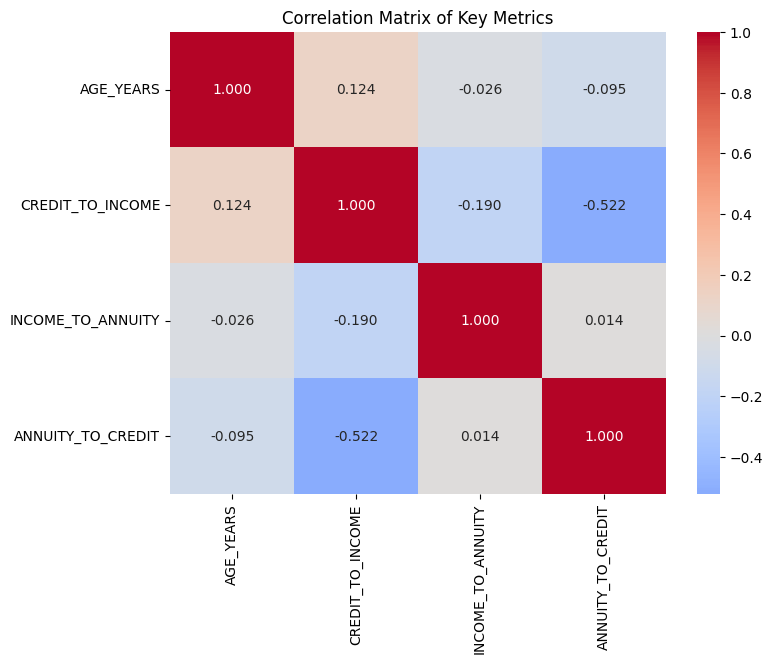


Analysis complete in Jupyter Notebook!


In [ ]:
# Cell 8: Final Summary
print("="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

if 'AGE_YEARS' in df_clean.columns:
    print(f"1. Age range: {df_clean['AGE_YEARS'].min():.0f} to {df_clean['AGE_YEARS'].max():.0f} years")
    print(f"   Most common age group: {age_dist.idxmax()} ({age_dist.max():,} applicants)")

if 'CREDIT_TO_INCOME' in df_clean.columns:
    print(f"2. Typical loan amount: {df_clean['CREDIT_TO_INCOME'].median():.1f}x annual income")

if 'ANNUITY_TO_CREDIT' in df_clean.columns:
    print(f"3. Typical annual payment: {df_clean['ANNUITY_TO_CREDIT'].median()*100:.1f}% of loan amount")

if 'INCOME_TO_ANNUITY' in df_clean.columns:
    print(f"4. Income covers annuity: {df_clean['INCOME_TO_ANNUITY'].median():.1f} times")

# Optional: Correlation matrix
print("\n" + "="*80)
print("CORRELATION MATRIX")
print("="*80)

correlation_cols = []
if 'AGE_YEARS' in df_clean.columns:
    correlation_cols.append('AGE_YEARS')
if 'CREDIT_TO_INCOME' in df_clean.columns:
    correlation_cols.append('CREDIT_TO_INCOME')
if 'INCOME_TO_ANNUITY' in df_clean.columns:
    correlation_cols.append('INCOME_TO_ANNUITY')
if 'ANNUITY_TO_CREDIT' in df_clean.columns:
    correlation_cols.append('ANNUITY_TO_CREDIT')

if len(correlation_cols) > 1:
    correlation_matrix = df_clean[correlation_cols].corr()
    print(correlation_matrix.round(3))
    
    # Visualize correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
    plt.title('Correlation Matrix of Key Metrics')
    plt.show()

print("\nAnalysis complete in Jupyter Notebook!")